<a href="https://colab.research.google.com/github/MajidSharaf/CampaignLens/blob/main/Pipeline/04_TopicModeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1: load cleaned data from step 1

In [2]:
!wget "https://raw.githubusercontent.com/MajidSharaf/CampaignLens/main/Datasets/Versions/comments_cleaned.csv"

--2026-06-13 10:11:30--  https://raw.githubusercontent.com/MajidSharaf/CampaignLens/main/Datasets/Versions/comments_cleaned.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2299025 (2.2M) [text/plain]
Saving to: ‘comments_cleaned.csv.1’

comments_cleaned.cs 100%[===================>]   2.19M  --.-KB/s    in 0.06s   

2026-06-13 10:11:30 (34.8 MB/s) - ‘comments_cleaned.csv.1’ saved [2299025/2299025]



In [3]:
import pandas as pd
import numpy as np
from tqdm import tqdm
tqdm.pandas()

In [4]:
df = pd.read_csv("/content/comments_cleaned.csv")
print(len(df))
df.head()

22174


,cleaned_text
0,not_want news google
1,trump dumbest president american history terri...
2,fareed know full well reason many objected jcp...
3,china 's xinjiang genocide million visited xin...
4,jet pilot need precision


Part 2: LDA topic modeling

Topic modeling is an unsupervised technique that discovers hidden themes in text.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt

In [6]:
vect = CountVectorizer(max_features=1000, max_df=.5)
X = vect.fit_transform(df["cleaned_text"])
print("Shape:", X.shape)

Shape: (22174, 1000)


In [7]:
lda = LatentDirichletAllocation(n_components=10, learning_method="batch",
                                max_iter=25, random_state=0)
document_topics = lda.fit_transform(X)
print("lda.components_.shape: {}".format(lda.components_.shape))

lda.components_.shape: (10, 1000)


In [8]:
sorting = np.argsort(lda.components_, axis=1)[:, ::-1]
feature_names = np.array(vect.get_feature_names_out())

for i, topic in enumerate(lda.components_):
    top_words = feature_names[sorting[i, :10]]
    print(f"Topic {i}: {' | '.join(top_words)}")

Topic 0: clapping_hands | ballroom | actually | news | stupid | question | fox | south | dumb | reporter
Topic 1: china | grinning_face_with_sweat | chinese | trade | usa | make | good | would | world | country
Topic 2: face_with_tears_of_joy | home | house | people | money | tax | family | ballroom | buy | price
Topic 3: eye | tear | trump | laughing | loud | see | biden | gold | office | would
Topic 4: rolling_on_the_floor_laughing | like | right | trump | wall | street | maga | get | oh | hilarious
Topic 5: muted_speaker | look | xi | like | trump | chair | walk | sitting | wonder | jinping
Topic 6: red_heart | god | trump | united_states | bless | thumbs_up | epstein | folded_hands | file | you
Topic 7: president | trump | great | house | white | love | thank | party_popper | best | mr
Topic 8: trump | xi | like | know | think | would | people | one | year | hand
Topic 9: trump | america | country | world | american | people | no | war | iran | state


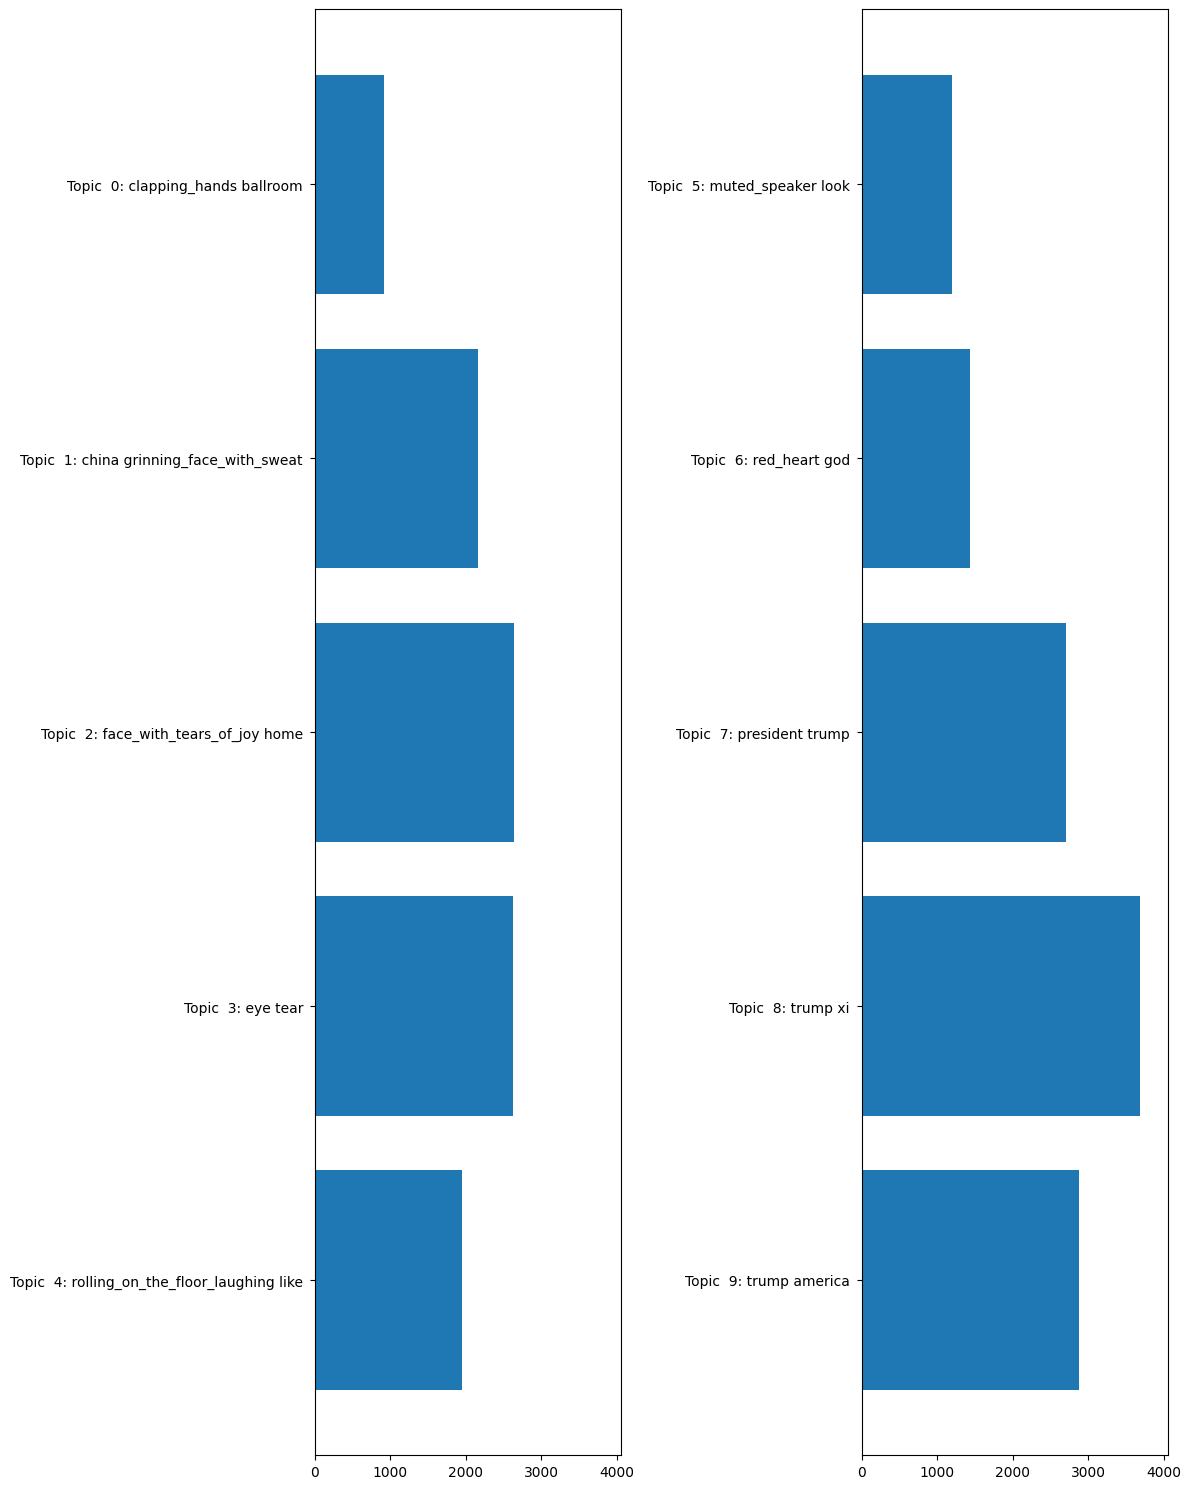

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 15))

topic_names = ["Topic {:>2}: ".format(i) + " ".join(words)
               for i, words in enumerate(feature_names[sorting[:, :2]])]

topic_weights = np.sum(document_topics, axis=0)

for col in [0, 1]:
    start = col * 5
    end = (col + 1) * 5
    current_weights = topic_weights[start:end]
    current_names = topic_names[start:end]
    y_pos = np.arange(len(current_weights))
    ax[col].barh(y_pos, current_weights, align='center')
    ax[col].set_yticks(y_pos)
    ax[col].set_yticklabels(current_names, ha="right", fontsize=10)
    ax[col].invert_yaxis()
    ax[col].set_xlim(0, topic_weights.max() * 1.1)
    yax = ax[col].get_yaxis()
    yax.set_tick_params(pad=5)

plt.tight_layout()
plt.show()

In [10]:
!pip install pyLDAvis
import pyLDAvis
import pyLDAvis.lda_model
import warnings
warnings.filterwarnings('ignore')
pyLDAvis.enable_notebook()

pyLDAvis.lda_model.prepare(lda, X, vect)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.8 MB/s eta 0:00:00


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
8     -0.118225 -0.082709       1        1  18.713902
9     -0.142110  0.004608       2        1  15.446305
1     -0.196875  0.056819       3        1  12.270693
2     -0.175213  0.055810       4        1  11.673965
7      0.083579 -0.105281       5        1  10.625337
3     -0.075696 -0.094278       6        1   9.773086
4     -0.083443 -0.082736       7        1   6.614854
6      0.363784 -0.090443       8        1   6.046819
5      0.206488 -0.102841       9        1   5.027107
0      0.137711  0.441052      10        1   3.807931, topic_info=                       Term         Freq        Total Category  logprob  \
564           muted_speaker  2752.000000  2752.000000  Default  30.0000   
725               red_heart  2896.000000  2896.000000  Default  29.0000   
154          clapping_hands  2263.000000  2263.000000  Default  28.0000   
298  face_with_tears_of_joy  2854.000000  2854.000000  Default  27.0000   
686               president  3178.000000  3178.000000  Default  26.0000   
..                      ...          ...          ...      ...      ...   
474                   laura    53.350538   158.868170  Topic10  -4.9416   
343                  future    49.064520   149.114583  Topic10  -5.0254   
572                     new    57.889453   403.672847  Topic10  -4.8600   
89                      big    55.705994   339.676518  Topic10  -4.8984   
38                 american    54.426202  1095.810502  Topic10  -4.9217   

     loglift  
564  30.0000  
725  29.0000  
154  28.0000  
298  27.0000  
686  26.0000  
..       ...  
474   2.1769  
343   2.1565  
572   1.3260  
89    1.4602  
38    0.2657  

[526 rows x 6 columns], token_table=      Topic      Freq Term
term                      
4         1  0.270548   30
4         2  0.019325   30
4         3  0.154599   30
4         4  0.193249   30
4         5  0.077299   30
...     ...       ...  ...
995       8  0.008512  yes
997       2  0.033393  you
997       3  0.169351  you
997       8  0.691715  you
997      10  0.104950  you

[1031 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[9, 10, 2, 3, 8, 4, 5, 7, 6, 1])

Part 3: BERTopic

BERTopic uses transformer embeddings instead of word counts and finds more specific topics automatically.

In [11]:
!pip install bertopic sentence_transformers
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

topic_model_Bert = BERTopic(embedding_model="xlm-r-bert-base-nli-stsb-mean-tokens")
bert_topics, _ = topic_model_Bert.fit_transform(df["cleaned_text"].tolist())

freq = topic_model_Bert.get_topic_info()
print("Number of topics: {}".format(len(freq)))
freq.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.6 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.82k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Number of topics: 217


,Topic,Count,Name,Representation,Representative_Docs
0,-1,10686,-1_muted_speaker_clapping_hands_president_trump,"[muted_speaker, clapping_hands, president, tru...",[let democrat head explode would done also wou...
1,0,1765,0_china_chinese_trade_world,"[china, chinese, trade, world, taiwan, xi, usa...",[patrick go live china get chinese product wan...
2,1,607,1_trump_donald_president_greatest,"[trump, donald, president, greatest, something...","[go donald trump, donald trump great president..."
3,2,389,2_japan_pearl_japanese_harbor,"[japan, pearl, japanese, harbor, attack, surpr...",[let sink made joke prime minister japan pearl...
4,3,305,3_home_housing_buying_investor,"[home, housing, buying, investor, rent, family...",[not_going work corporation not_what housing p...


In [12]:
topic_model_Bert.visualize_barchart(top_n_topics=10)

In [13]:
topic_model_Bert.visualize_hierarchy(top_n_topics=15)

Part 4: topic modeling per sentiment

In [14]:
# load sentiment results from step 3
!wget "https://raw.githubusercontent.com/MajidSharaf/CampaignLens/main/Datasets/Versions/sentiment_results.csv"
df_sentiment = pd.read_csv("/content/sentiment_results.csv")
print(df_sentiment.head())

--2026-06-13 10:59:50--  https://raw.githubusercontent.com/MajidSharaf/CampaignLens/main/Datasets/Versions/sentiment_results.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2400959 (2.3M) [text/plain]
Saving to: ‘sentiment_results.csv’

sentiment_results.c 100%[===================>]   2.29M  --.-KB/s    in 0.06s   

2026-06-13 10:59:50 (37.9 MB/s) - ‘sentiment_results.csv’ saved [2400959/2400959]

                                        cleaned_text  Vader  RoBERTa
0                               not_want news google      0       -1
1  trump dumbest president american history terri...     -1       -1
2  fareed know full well reason many objected jcp...     -1       -1
3  china 's xinjiang genocide million visited xin...     -1       -1
4                 

In [15]:
# split by sentiment
positive_comments = df_sentiment[df_sentiment["RoBERTa"] == 1]["cleaned_text"]
negative_comments = df_sentiment[df_sentiment["RoBERTa"] == -1]["cleaned_text"]
neutral_comments  = df_sentiment[df_sentiment["RoBERTa"] == 0]["cleaned_text"]

print("Positive:", len(positive_comments))
print("Negative:", len(negative_comments))
print("Neutral:",  len(neutral_comments))

Positive: 4612
Negative: 7101
Neutral: 10461


In [16]:
def runLDA(comments, label):
    vect_s = CountVectorizer(max_features=1000, max_df=.5)
    X_s = vect_s.fit_transform(comments)

    lda_s = LatentDirichletAllocation(n_components=5, learning_method="batch",
                                      max_iter=25, random_state=0)
    lda_s.fit_transform(X_s)

    sorting_s = np.argsort(lda_s.components_, axis=1)[:, ::-1]
    feature_names_s = np.array(vect_s.get_feature_names_out())

    print(f"\n=== {label} Comments ===")
    for i, topic in enumerate(lda_s.components_):
        top_words = feature_names_s[sorting_s[i, :8]]
        print(f"Topic {i}: {' | '.join(top_words)}")

runLDA(positive_comments, "Positive")
runLDA(negative_comments, "Negative")
runLDA(neutral_comments,  "Neutral")


=== Positive Comments ===
Topic 0: face_with_tears_of_joy | thumbs_up | smiling_face_with_smiling_eyes | you | china | _outlying_islands | xi | trump
Topic 1: trump | president | house | great | white | love | beautiful | look
Topic 2: red_heart | trump | god | president | bless | united_states | thank | love
Topic 3: best | president | ever | greatest | trump | good | something | one
Topic 4: good | great | laughing | love | loud | video | guy | actually

=== Negative Comments ===
Topic 0: democrat | trump | people | home | money | house | ballroom | tax
Topic 1: china | people | money | no | like | state | would | make
Topic 2: trump | president | face_with_tears_of_joy | xi | like | would | hate | people
Topic 3: trump | like | look | eye | tear | laughing | president | no
Topic 4: trump | china | america | country | world | war | american | iran

=== Neutral Comments ===
Topic 0: trump | like | people | would | one | eye | president | see
Topic 1: trump | xi | president | china | 